## Dataset helpers testing script

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

from model.data_utils import (
    ZINBDataset,
    get_X_features,
    get_reference_features,
    load_expression_dataset,
)
from model.model_utils import (
    OrionLoss,
    OrionVAE,
    evaluate_test_set,
    plot_training_results,
    run_dataset_inference,
    train_orion,
)

TRAIN_DATASET = "tissue"  # "tissue" or "circulating"
N_SIGNAL_FEATURES = 32
N_REFERENCE_FEATURES = 64
FEATURE_METHOD = "mannwhitneyu"
BATCH_SIZE = 4
RANDOM_STATE = 42
SEEDS = [7, 11, 19, 29, 37, 55, 79, 97, 123, 151, 333, 555, 777, 999, 2026]
SEEDS = [7, 11, 19, 29, 37, 55]
EPOCHS = 75
LEARNING_RATE = 1e-3
USE_FEATURE_LEAKAGE = False
MODEL_PATH = Path("model/orion_breast_cancer_model.pth")

counts_matrix, labels = load_expression_dataset(TRAIN_DATASET, data_mode="count")
print(f"Loaded {TRAIN_DATASET} dataset with shape {counts_matrix.shape}")
print(f"Class counts: cancer={int(labels.sum())}, healthy={int((labels == 0).sum())}")


def run_multisplit_experiment(
    counts_df,
    labels_array,
    dataset_tag,
    seeds,
    epochs,
    lr,
    device,
    n_signal_features,
    n_reference_features,
    feature_method,
    batch_size,
    use_feature_leakage=True,
):
    split_rows = []
    best_artifact = None
    best_auc = -1.0

    for split_seed in seeds:
        print("\n" + "=" * 60)
        print(f"{dataset_tag.upper()} | split seed={split_seed}")
        print("=" * 60)

        indices = np.arange(len(labels_array))
        train_val_idx, test_idx = train_test_split(
            indices,
            test_size=0.15,
            stratify=labels_array,
            random_state=split_seed,
        )
        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=0.176,
            stratify=labels_array[train_val_idx],
            random_state=split_seed,
        )

        if use_feature_leakage:
            select_counts = counts_df
            select_labels = labels_array
        else:
            select_counts = counts_df.iloc[train_idx]
            select_labels = labels_array[train_idx]

        signal_cols_local = get_X_features(
            select_counts,
            select_labels,
            method=feature_method,
            n_features=n_signal_features,
        )
        ref_cols_local = get_reference_features(
            select_counts,
            n_features=n_reference_features,
        )

        full_dataset_local = ZINBDataset(counts_df, labels_array, signal_cols_local, ref_cols_local)
        train_loader_local = DataLoader(Subset(full_dataset_local, train_idx), batch_size=batch_size, shuffle=True)
        val_loader_local = DataLoader(Subset(full_dataset_local, val_idx), batch_size=batch_size, shuffle=False)
        test_loader_local = DataLoader(Subset(full_dataset_local, test_idx), batch_size=batch_size, shuffle=False)

        model_local = OrionVAE(
            x_dim=len(signal_cols_local),
            r_dim=len(ref_cols_local),
            z_dim=32,
        )

        history_local = train_orion(
            model=model_local,
            train_loader=train_loader_local,
            val_loader=val_loader_local,
            epochs=epochs,
            lr=lr,
            device=device,
            recon_mode="zinb",
        )

        loss_fn_local = OrionLoss(beta=0.01, gamma=10.0, recon_mode="zinb").to(device)
        test_probs_local, test_targets_local = evaluate_test_set(
            model_local,
            test_loader_local,
            loss_fn_local,
            device,
        )

        split_auc = roc_auc_score(test_targets_local, test_probs_local)
        split_acc = accuracy_score(test_targets_local, (test_probs_local > 0.5).astype(int))

        split_rows.append(
            {
                "seed": split_seed,
                "test_auc": split_auc,
                "test_acc": split_acc,
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "n_test": len(test_idx),
            }
        )

        if split_auc > best_auc:
            best_auc = split_auc
            best_artifact = {
                "seed": split_seed,
                "model": model_local,
                "history": history_local,
                "signal_cols": signal_cols_local,
                "ref_cols": ref_cols_local,
                "train_idx": train_idx.copy(),
                "val_idx": val_idx.copy(),
                "test_idx": test_idx.copy(),
                "test_loader": test_loader_local,
                "test_probs": test_probs_local,
                "test_targets": test_targets_local,
            }

    summary_df = pd.DataFrame(split_rows)
    print("\n--- Multi-split Summary ---")
    print(summary_df)
    print(
        f"AUC mean={summary_df['test_auc'].mean():.4f} std={summary_df['test_auc'].std(ddof=0):.4f} | "
        f"ACC mean={summary_df['test_acc'].mean():.4f} std={summary_df['test_acc'].std(ddof=0):.4f}"
    )
    print(f"Best split seed={best_artifact['seed']} AUC={best_auc:.4f}")

    return summary_df, best_artifact



Loaded tissue dataset with shape (180, 3538)
Class counts: cancer=120, healthy=60


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
if "signal_cols" not in globals() or "ref_cols" not in globals():
    print("Run the split/feature-selection cell first to initialize signal_cols/ref_cols.")
else:
    dataset_preview = ZINBDataset(counts_matrix, labels, signal_cols, ref_cols)
    preview_loader = DataLoader(dataset_preview, batch_size=BATCH_SIZE, shuffle=True)

    x_batch, r_batch, l_batch, y_batch = next(iter(preview_loader))
    print(f"Batch X Shape: {x_batch.shape}")
    print(f"Batch R Shape: {r_batch.shape}")
    print("Data pipeline ready!")


Run the split/feature-selection cell first to initialize signal_cols/ref_cols.


In [4]:
print(
    f"Preparing 5-split experiment for {TRAIN_DATASET} | "
    f"epochs={EPOCHS} | leakage={USE_FEATURE_LEAKAGE}"
)

Preparing 5-split experiment for tissue | epochs=75 | leakage=False


## Running the model
1. Split data into training and validation sets.
2. Initialize the model with the correct dimensions.
3. Execute the training loop using the train_orion function.

In [5]:
# Model is created inside each split in the multi-split runner.

print("\n--- Starting Multi-Split Training ---")
primary_summary_df, primary_best = run_multisplit_experiment(
    counts_df=counts_matrix,
    labels_array=labels,
    dataset_tag=TRAIN_DATASET,
    seeds=SEEDS,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    n_signal_features=N_SIGNAL_FEATURES,
    n_reference_features=N_REFERENCE_FEATURES,
    feature_method=FEATURE_METHOD,
    batch_size=BATCH_SIZE,
    use_feature_leakage=USE_FEATURE_LEAKAGE,
)

model = primary_best["model"]
history = primary_best["history"]
signal_cols = primary_best["signal_cols"]
ref_cols = primary_best["ref_cols"]
primary_train_idx = primary_best["train_idx"]
primary_val_idx = primary_best["val_idx"]
primary_test_idx = primary_best["test_idx"]
test_loader = primary_best["test_loader"]
test_probs = primary_best["test_probs"]
test_targets = primary_best["test_targets"]

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved best {TRAIN_DATASET} model to '{MODEL_PATH}'")



--- Starting Multi-Split Training ---

TISSUE | split seed=7
Selecting top 32 signal features...
Starting training on cpu for 75 epochs (recon_mode=zinb)...
Epoch 005 | Loss: 791.5721 | Val AUC: 1.0000 | Val Acc: 0.7778
Epoch 010 | Loss: 527.2144 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 015 | Loss: 502.8029 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 020 | Loss: 492.8107 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 025 | Loss: 485.6195 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 030 | Loss: 476.6105 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 035 | Loss: 479.4844 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 040 | Loss: 467.0468 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 045 | Loss: 465.0893 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 050 | Loss: 458.7389 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 055 | Loss: 458.2534 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 060 | Loss: 449.4284 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 065 | Loss: 446.8511 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 070 | Loss: 447.7

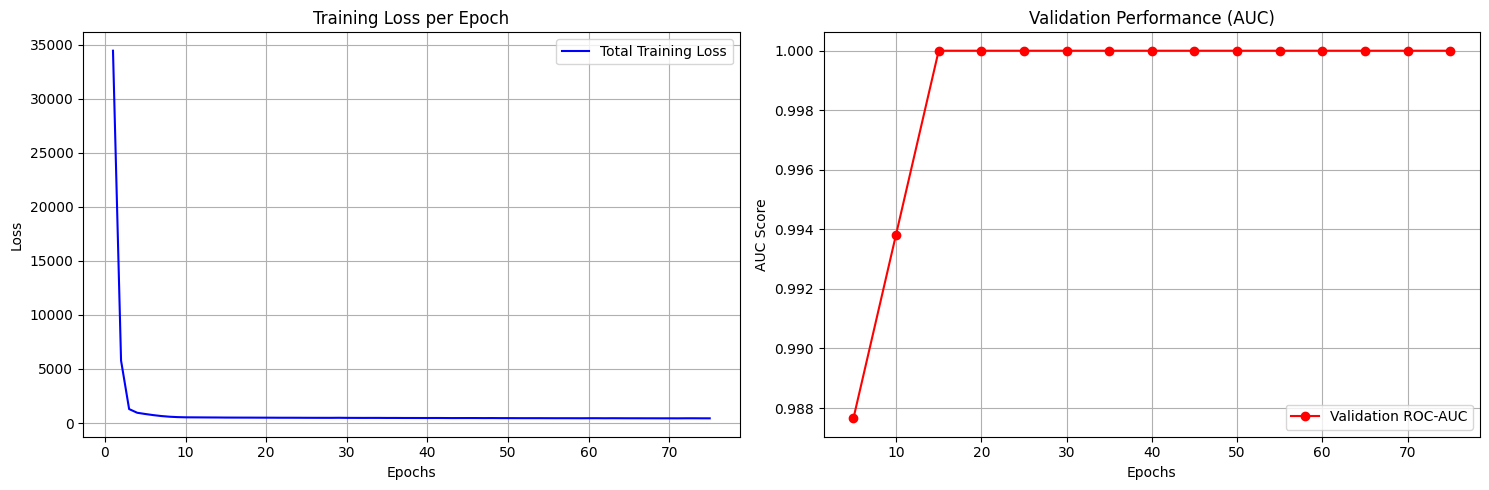

In [6]:
plot_training_results(history)


In [7]:
print("Primary dataset 5-split summary:")
print(primary_summary_df)
print(
    f"AUC mean={primary_summary_df['test_auc'].mean():.4f} | "
    f"ACC mean={primary_summary_df['test_acc'].mean():.4f}"
)
print(f"Downstream plots use best-seed model: {primary_best['seed']}")


Primary dataset 5-split summary:
   seed  test_auc  test_acc  n_train  n_val  n_test
0     7  0.993827  0.888889      126     27      27
1    11  0.975309  0.888889      126     27      27
2    19  1.000000  0.962963      126     27      27
3    29  0.956790  0.925926      126     27      27
4    37  0.925926  0.777778      126     27      27
5    55  0.993827  0.925926      126     27      27
AUC mean=0.9743 | ACC mean=0.8951
Downstream plots use best-seed model: 19



--- Starting Circulating Multi-Split Training ---

CIRCULATING | split seed=7
Selecting top 32 signal features...
Starting training on cpu for 75 epochs (recon_mode=zinb)...
Epoch 005 | Loss: 549.1513 | Val AUC: 0.9444 | Val Acc: 0.8667
Epoch 010 | Loss: 363.2763 | Val AUC: 0.9630 | Val Acc: 0.9333
Epoch 015 | Loss: 309.1262 | Val AUC: 0.9630 | Val Acc: 0.9333
Epoch 020 | Loss: 286.8940 | Val AUC: 0.9815 | Val Acc: 0.8667
Epoch 025 | Loss: 281.3953 | Val AUC: 0.9815 | Val Acc: 0.8667
Epoch 030 | Loss: 264.2351 | Val AUC: 0.9815 | Val Acc: 0.8667
Epoch 035 | Loss: 254.6417 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 040 | Loss: 252.6004 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 045 | Loss: 239.9142 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 050 | Loss: 238.7160 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 055 | Loss: 229.6973 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch 060 | Loss: 223.8334 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch 065 | Loss: 215.6471 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch 

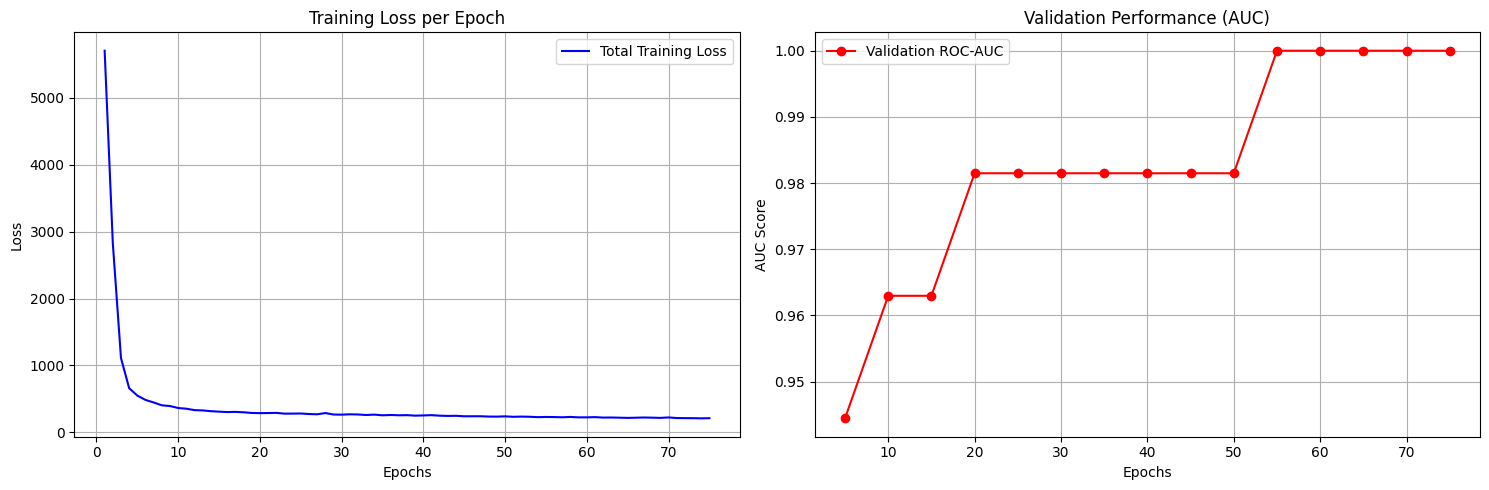

Saved best circulating model to 'model\orion_circulating_model.pth'


In [8]:
# Additional experiment: train and evaluate on circulating RNA (5-split average)
CIRCULATING_EPOCHS = EPOCHS

counts_circ, labels_circ = load_expression_dataset("circulating", data_mode="count")

print("\n--- Starting Circulating Multi-Split Training ---")
circ_summary_df, circ_best = run_multisplit_experiment(
    counts_df=counts_circ,
    labels_array=labels_circ,
    dataset_tag="circulating",
    seeds=SEEDS,
    epochs=CIRCULATING_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    n_signal_features=N_SIGNAL_FEATURES,
    n_reference_features=N_REFERENCE_FEATURES,
    feature_method=FEATURE_METHOD,
    batch_size=BATCH_SIZE,
    use_feature_leakage=USE_FEATURE_LEAKAGE,
)

model_circ = circ_best["model"]
history_circ = circ_best["history"]
signal_cols_circ = circ_best["signal_cols"]
ref_cols_circ = circ_best["ref_cols"]
circ_train_idx = circ_best["train_idx"]
circ_val_idx = circ_best["val_idx"]
circ_test_idx = circ_best["test_idx"]
test_loader_circ = circ_best["test_loader"]
test_probs_circ = circ_best["test_probs"]
test_targets_circ = circ_best["test_targets"]

plot_training_results(history_circ)

model_circ_path = Path("model/orion_circulating_model.pth")
model_circ_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model_circ.state_dict(), model_circ_path)
print(f"Saved best circulating model to '{model_circ_path}'")


In [9]:
print("Circulating dataset 5-split summary:")
print(circ_summary_df)
print(
    f"AUC mean={circ_summary_df['test_auc'].mean():.4f} | "
    f"ACC mean={circ_summary_df['test_acc'].mean():.4f}"
)
print(f"Downstream plots use best-seed model: {circ_best['seed']}")


Circulating dataset 5-split summary:
   seed  test_auc  test_acc  n_train  n_val  n_test
0     7  1.000000  1.000000       66     15      15
1    11  0.907407  0.733333       66     15      15
2    19  0.851852  0.800000       66     15      15
3    29  0.925926  0.866667       66     15      15
4    37  0.833333  0.666667       66     15      15
5    55  0.981481  0.933333       66     15      15
AUC mean=0.9167 | ACC mean=0.8333
Downstream plots use best-seed model: 7


c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


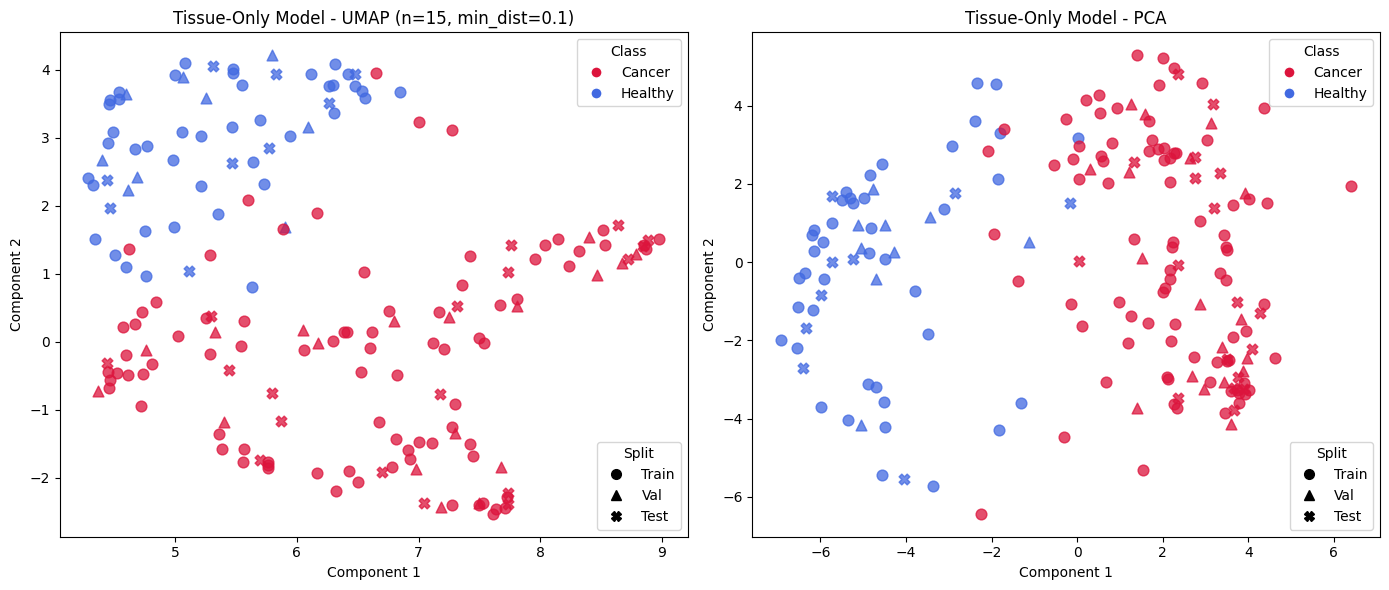


Tissue-Only Model latent metrics
--------------------------------------------------
Silhouette score:           0.2633
Calinski-Harabasz score:    64.0135
Davies-Bouldin score:       1.4567
Linear separability AUC:    1.0000
Linear separability ACC:    0.9259
--------------------------------------------------


c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


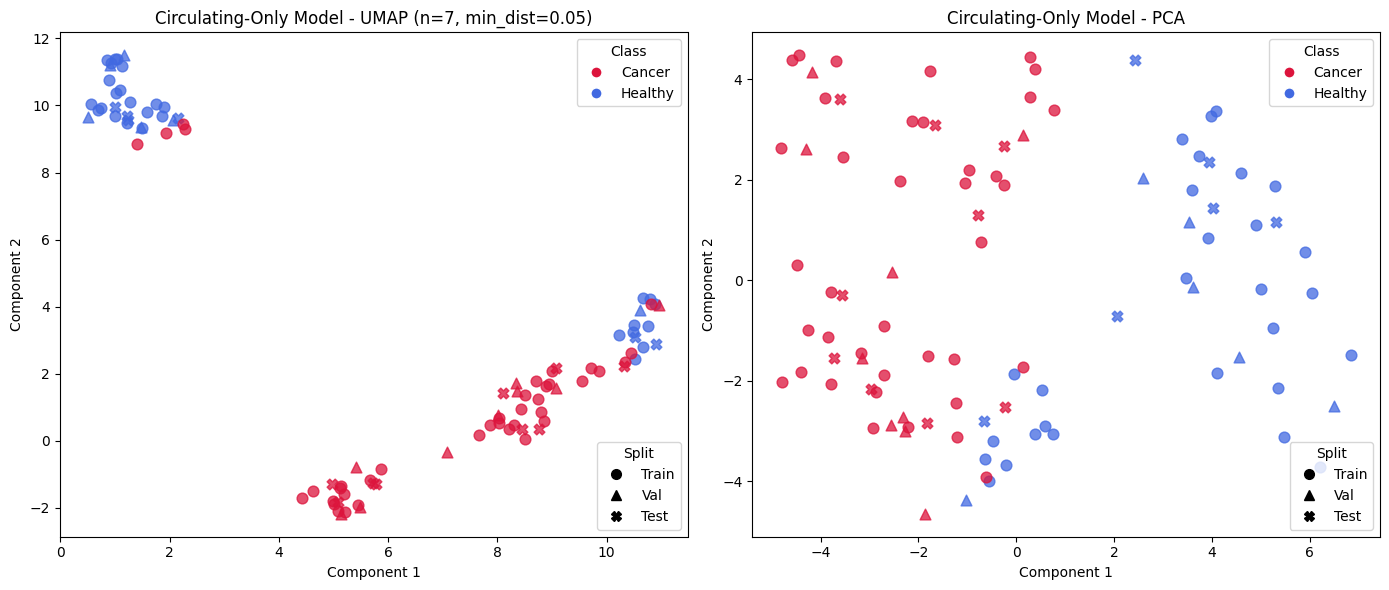


Circulating-Only Model latent metrics
--------------------------------------------------
Silhouette score:           0.1985
Calinski-Harabasz score:    24.9203
Davies-Bouldin score:       1.8839
Linear separability AUC:    1.0000
Linear separability ACC:    1.0000
--------------------------------------------------


In [10]:
from umap import UMAP
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    roc_auc_score,
    silhouette_score,
)


def _build_loader_from_indices(counts_df, labels_array, signal_features, ref_features, indices):
    ds = ZINBDataset(counts_df, labels_array, signal_features, ref_features)
    return DataLoader(Subset(ds, indices), batch_size=BATCH_SIZE, shuffle=False)


def _extract_latents(model_obj, loader_obj, split_name):
    model_obj.eval()
    z_chunks = []
    y_chunks = []
    split_chunks = []

    with torch.no_grad():
        for x, r, _, y in loader_obj:
            z, _, _, _, _, _ = model_obj.encoder(x.to(device), r.to(device))
            z_np = z.cpu().numpy()
            y_np = y.numpy().reshape(-1)
            z_chunks.append(z_np)
            y_chunks.append(y_np)
            split_chunks.append(np.array([split_name] * len(y_np)))

    return np.concatenate(z_chunks), np.concatenate(y_chunks), np.concatenate(split_chunks)


def _compute_latent_metrics(z_train, y_train, z_all, y_all, z_test, y_test):
    metrics = {}

    if len(np.unique(y_all)) > 1 and len(z_all) > 2:
        metrics["silhouette"] = float(silhouette_score(z_all, y_all))
        metrics["calinski_harabasz"] = float(calinski_harabasz_score(z_all, y_all))
        metrics["davies_bouldin"] = float(davies_bouldin_score(z_all, y_all))
    else:
        metrics["silhouette"] = np.nan
        metrics["calinski_harabasz"] = np.nan
        metrics["davies_bouldin"] = np.nan

    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(z_train, y_train)
    test_probs = clf.predict_proba(z_test)[:, 1]
    test_pred = (test_probs > 0.5).astype(int)
    metrics["linear_auc_test"] = float(roc_auc_score(y_test, test_probs))
    metrics["linear_acc_test"] = float(accuracy_score(y_test, test_pred))

    return metrics


def _scatter_by_class_and_split(ax, emb, y, split_names, title):
    class_colors = {0: "royalblue", 1: "crimson"}
    split_markers = {"train": "o", "val": "^", "test": "X"}

    for cls in [0, 1]:
        for split_name, marker in split_markers.items():
            idx = (y == cls) & (split_names == split_name)
            if np.any(idx):
                ax.scatter(
                    emb[idx, 0],
                    emb[idx, 1],
                    c=class_colors[cls],
                    marker=marker,
                    s=60,
                    alpha=0.75,
                )

    class_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson", label="Cancer", markersize=8),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="royalblue", label="Healthy", markersize=8),
    ]
    split_handles = [
        Line2D([0], [0], marker="o", color="black", linestyle="None", label="Train", markersize=7),
        Line2D([0], [0], marker="^", color="black", linestyle="None", label="Val", markersize=7),
        Line2D([0], [0], marker="X", color="black", linestyle="None", label="Test", markersize=7),
    ]

    leg1 = ax.legend(handles=class_handles, loc="upper right", title="Class")
    ax.add_artist(leg1)
    ax.legend(handles=split_handles, loc="lower right", title="Split")
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")


def plot_latent_diagnostics(
    model_obj,
    counts_df,
    labels_array,
    signal_features,
    ref_features,
    train_idx,
    val_idx,
    test_idx,
    title_prefix,
    umap_n_neighbors,
    umap_min_dist,
):
    train_loader = _build_loader_from_indices(counts_df, labels_array, signal_features, ref_features, train_idx)
    val_loader = _build_loader_from_indices(counts_df, labels_array, signal_features, ref_features, val_idx)
    test_loader = _build_loader_from_indices(counts_df, labels_array, signal_features, ref_features, test_idx)

    z_train, y_train, split_train = _extract_latents(model_obj, train_loader, "train")
    z_val, y_val, split_val = _extract_latents(model_obj, val_loader, "val")
    z_test, y_test, split_test = _extract_latents(model_obj, test_loader, "test")

    z_all = np.vstack([z_train, z_val, z_test])
    y_all = np.concatenate([y_train, y_val, y_test]).astype(int)
    split_all = np.concatenate([split_train, split_val, split_test])

    umap_emb = UMAP(
        n_neighbors=umap_n_neighbors,
        min_dist=umap_min_dist,
        random_state=42,
    ).fit_transform(z_all)
    pca_emb = PCA(n_components=2, random_state=42).fit_transform(z_all)

    metrics = _compute_latent_metrics(z_train, y_train, z_all, y_all, z_test, y_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    _scatter_by_class_and_split(
        axes[0],
        umap_emb,
        y_all,
        split_all,
        f"{title_prefix} - UMAP (n={umap_n_neighbors}, min_dist={umap_min_dist})",
    )
    _scatter_by_class_and_split(
        axes[1],
        pca_emb,
        y_all,
        split_all,
        f"{title_prefix} - PCA",
    )
    plt.tight_layout()
    plt.show()

    print(f"\n{title_prefix} latent metrics")
    print("-" * 50)
    print(f"Silhouette score:           {metrics['silhouette']:.4f}")
    print(f"Calinski-Harabasz score:    {metrics['calinski_harabasz']:.4f}")
    print(f"Davies-Bouldin score:       {metrics['davies_bouldin']:.4f}")
    print(f"Linear separability AUC:    {metrics['linear_auc_test']:.4f}")
    print(f"Linear separability ACC:    {metrics['linear_acc_test']:.4f}")
    print("-" * 50)


# 1) Tissue model diagnostics (train+val+test together)
plot_latent_diagnostics(
    model_obj=model,
    counts_df=counts_matrix,
    labels_array=labels,
    signal_features=signal_cols,
    ref_features=ref_cols,
    train_idx=primary_train_idx,
    val_idx=primary_val_idx,
    test_idx=primary_test_idx,
    title_prefix="Tissue-Only Model",
    umap_n_neighbors=15,
    umap_min_dist=0.1,
)

# 2) Circulating model diagnostics with smaller UMAP values
if "model_circ" in globals():
    plot_latent_diagnostics(
        model_obj=model_circ,
        counts_df=counts_circ,
        labels_array=labels_circ,
        signal_features=signal_cols_circ,
        ref_features=ref_cols_circ,
        train_idx=circ_train_idx,
        val_idx=circ_val_idx,
        test_idx=circ_test_idx,
        title_prefix="Circulating-Only Model",
        umap_n_neighbors=7,
        umap_min_dist=0.05,
    )
else:
    print("Run the circulating multi-split cell first to view circulating diagnostics.")


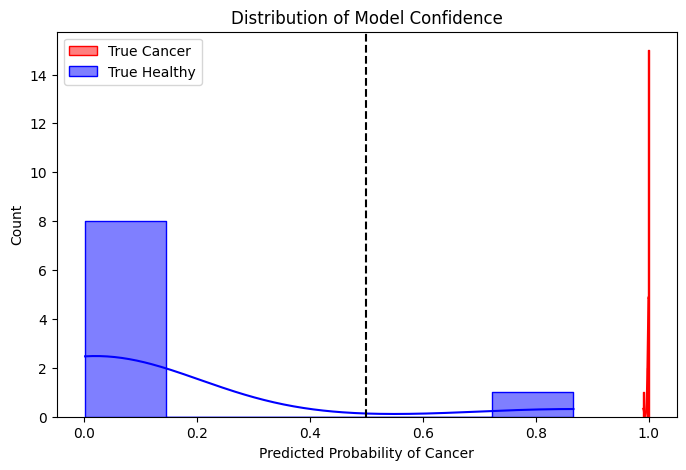

In [11]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(test_probs[test_targets == 1], color="red", label="True Cancer", kde=True, element="step")
sns.histplot(test_probs[test_targets == 0], color="blue", label="True Healthy", kde=True, element="step")
plt.axvline(0.5, color="black", linestyle="--")
plt.title("Distribution of Model Confidence")
plt.xlabel("Predicted Probability of Cancer")
plt.legend()
plt.show()


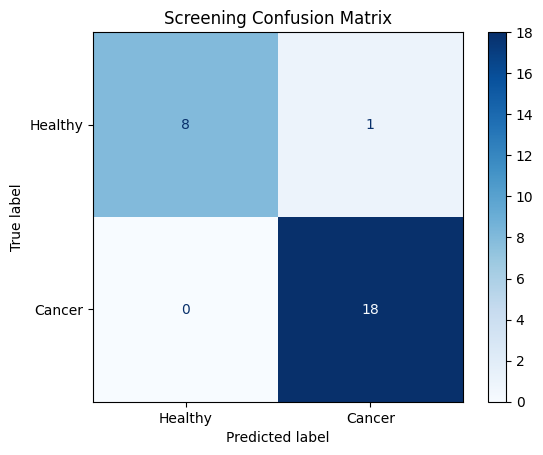

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

preds_binary = (test_probs > 0.5).astype(int)
cm = confusion_matrix(test_targets, preds_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Cancer"])
disp.plot(cmap="Blues")
plt.title("Screening Confusion Matrix")
plt.show()


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score

INFERENCE_DATASET = "circulating" if TRAIN_DATASET == "tissue" else "tissue"
inference_counts, inference_labels = load_expression_dataset(INFERENCE_DATASET, data_mode="count")

signal_overlap = len(set(signal_cols).intersection(inference_counts.columns))
ref_overlap = len(set(ref_cols).intersection(inference_counts.columns))
print(
    f"Feature overlap with {INFERENCE_DATASET}: signal {signal_overlap}/{len(signal_cols)}, "
    f"reference {ref_overlap}/{len(ref_cols)}"
)

inference_probs, inference_targets = run_dataset_inference(
    model=model,
    counts_df=inference_counts,
    signal_features=signal_cols,
    ref_features=ref_cols,
    labels=inference_labels,
    batch_size=BATCH_SIZE,
    device=device,
)

inference_binary = (inference_probs > 0.5).astype(int)
inference_auc = roc_auc_score(inference_targets, inference_probs)
inference_acc = accuracy_score(inference_targets, inference_binary)

print(f"{TRAIN_DATASET} -> {INFERENCE_DATASET} inference AUC: {inference_auc:.4f}")
print(f"{TRAIN_DATASET} -> {INFERENCE_DATASET} inference ACC: {inference_acc:.4f}")


Feature overlap with circulating: signal 18/32, reference 27/64
tissue -> circulating inference AUC: 0.3612
tissue -> circulating inference ACC: 0.4583


# multiclass dataset - pancancer model

Diagnostic objective:
- Stage 1: cancer vs non-cancer (benign included in non-cancer)
- Stage 2: cancer-type classifier on predicted cancer samples

In [14]:
# Phase 1 diagnostics: serum pancancer matrix + metadata loader
import numpy as np
from model.data_utils import load_serum_pancancer_dataset

panc_counts, panc_meta, panc_maps, panc_info = load_serum_pancancer_dataset(data_mode="normalized", return_info=True)

print("Pancancer expression shape [samples, features]:", panc_counts.shape)
print("Data mode:", panc_info["data_mode"], "| inferred:", panc_info["inferred_data_mode"])
print("Aligned metadata rows:", panc_meta.shape[0])
print("Sample index alignment:", panc_counts.index.equals(panc_meta.index))

print("\nDisease-state counts:")
print(panc_meta["Disease State"].value_counts())

print("\nStage1 group counts:")
print(panc_meta["stage1_group"].value_counts())

print("\nStage1 label distribution (1=cancer, 0=non-cancer):")
print(panc_meta["stage1_label"].value_counts().sort_index())

cancer_only = panc_meta[panc_meta["stage2_label"] >= 0]
print("\nStage2 cancer classes:", cancer_only["stage2_label"].nunique())
print("Stage2 class map (first 10):")
print(list(panc_maps["stage2_class_to_index"].items())[:10])

values = panc_counts.to_numpy(dtype=np.float32, copy=False)
print("\nExpression matrix stats:")
print(f"min={values.min():.4f}, max={values.max():.4f}, mean={values.mean():.4f}, std={values.std():.4f}")
print(f"zero fraction={(values == 0).mean():.6f}")



Pancancer expression shape [samples, features]: (16190, 2565)
Data mode: normalized | inferred: normalized
Aligned metadata rows: 16190
Sample index alignment: True

Disease-state counts:
Disease State
no cancer                                                       5643
lung cancer                                                     1699
colorectal cancer                                               1596
gastric cancer                                                  1418
prostate cancer                                                 1027
pancreatic cancer                                                851
breast cancer                                                    675
esophageal squamous cell cancer                                  566
biliary tract cancer                                             402
ovarian cancer                                                   400
bladder cancer                                                   399
hepatocellular cancer                  

## Phase 3 - Stage 1 + Stage 2 training and latent analysis

This section adds:
- Stage 1 training: cancer vs non-cancer
- Stage 2 training: 13-way cancer type classification (cancer-only samples)
- Per-epoch training loss and validation curves for both stages
- Latent space analysis for stage 1 and stage 2


In [15]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from umap import UMAP
from torch.utils.data import DataLoader, Subset

from model.data_utils import (
    ZINBDataset,
    get_X_features,
    get_reference_features,
    load_serum_pancancer_dataset,
)
from model.model_utils import OrionLoss, OrionVAE, evaluate_test_set, train_orion


def stratified_train_val_test_indices(labels, test_size=0.15, val_size=0.15, random_state=42):
    labels = np.asarray(labels)
    indices = np.arange(len(labels))

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        stratify=labels,
        random_state=random_state,
    )

    val_frac_of_trainval = val_size / (1.0 - test_size)
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=val_frac_of_trainval,
        stratify=labels[train_val_idx],
        random_state=random_state,
    )

    return train_idx, val_idx, test_idx


def select_multiclass_signal_features_anova(counts_df, labels, n_features=256):
    y = np.asarray(labels).astype(int)
    X = counts_df.to_numpy(dtype=np.float32, copy=False)

    scores, pvals = f_classif(X, y)
    scores = np.nan_to_num(scores, nan=-np.inf, posinf=-np.inf, neginf=-np.inf)

    top_idx = np.argsort(scores)[::-1][:n_features]
    return counts_df.columns[top_idx].tolist()


def plot_history_with_validation(history, title, eval_every=5):
    train_loss = history.get("train_loss", [])
    val_auc = history.get("val_auc", [])
    val_acc = history.get("val_acc", [])

    epochs = np.arange(1, len(train_loss) + 1)
    val_epochs = np.arange(eval_every, eval_every * len(val_auc) + 1, eval_every)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_loss, color="navy", linewidth=2, label="Train loss")
    axes[0].set_title(f"{title} - Training loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if len(val_auc) > 0:
        axes[1].plot(val_epochs, val_auc, marker="o", color="crimson", label="Val AUC")
        axes[1].plot(val_epochs, val_acc, marker="s", color="darkgreen", label="Val ACC")
    axes[1].set_title(f"{title} - Validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def extract_latents_by_indices(model_obj, dataset_obj, split_index_map, batch_size, device):
    model_obj.eval()

    all_z, all_y, all_split = [], [], []

    with torch.no_grad():
        for split_name, split_indices in split_index_map.items():
            loader = DataLoader(Subset(dataset_obj, split_indices), batch_size=batch_size, shuffle=False)
            for x, r, _, y in loader:
                z, _, _, _, _, _ = model_obj.encoder(x.to(device), r.to(device))
                all_z.append(z.detach().cpu().numpy())
                all_y.append(y.detach().cpu().numpy().reshape(-1))
                all_split.append(np.array([split_name] * len(y)))

    z_all = np.concatenate(all_z, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    split_all = np.concatenate(all_split, axis=0)
    return z_all, y_all, split_all


def plot_stage1_latent(model_obj, dataset_obj, split_index_map, batch_size, device, title):
    z_all, y_all, split_all = extract_latents_by_indices(
        model_obj, dataset_obj, split_index_map, batch_size, device
    )

    y_all = y_all.astype(int)
    umap_emb = UMAP(n_neighbors=20, min_dist=0.1, random_state=42).fit_transform(z_all)
    pca_emb = PCA(n_components=2, random_state=42).fit_transform(z_all)

    class_colors = {0: "royalblue", 1: "crimson"}
    split_markers = {"train": "o", "val": "^", "test": "X"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, emb, name in [
        (axes[0], umap_emb, "UMAP"),
        (axes[1], pca_emb, "PCA"),
    ]:
        for cls in [0, 1]:
            for split_name, marker in split_markers.items():
                idx = (y_all == cls) & (split_all == split_name)
                if np.any(idx):
                    ax.scatter(
                        emb[idx, 0],
                        emb[idx, 1],
                        c=class_colors[cls],
                        marker=marker,
                        s=26,
                        alpha=0.75,
                    )

        class_handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson", label="Cancer", markersize=8),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="royalblue", label="Non-cancer", markersize=8),
        ]
        split_handles = [
            Line2D([0], [0], marker="o", color="black", linestyle="None", label="Train", markersize=7),
            Line2D([0], [0], marker="^", color="black", linestyle="None", label="Val", markersize=7),
            Line2D([0], [0], marker="X", color="black", linestyle="None", label="Test", markersize=7),
        ]
        leg1 = ax.legend(handles=class_handles, loc="upper right", title="Class")
        ax.add_artist(leg1)
        ax.legend(handles=split_handles, loc="lower right", title="Split")

        ax.set_title(f"{title} - {name}")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")

    plt.tight_layout()
    plt.show()


def plot_stage2_latent(model_obj, dataset_obj, split_index_map, batch_size, device, class_index_to_name, title):
    z_all, y_all, split_all = extract_latents_by_indices(
        model_obj, dataset_obj, split_index_map, batch_size, device
    )

    y_all = y_all.astype(int)
    umap_emb = UMAP(n_neighbors=20, min_dist=0.15, random_state=42).fit_transform(z_all)

    classes = sorted(np.unique(y_all).tolist())
    class_names = [class_index_to_name[int(c)] for c in classes]

    palette = plt.cm.get_cmap("tab20", max(len(classes), 13))
    class_to_color = {c: palette(i) for i, c in enumerate(classes)}

    # Combined multiclass map
    plt.figure(figsize=(10, 7))
    for c in classes:
        idx = y_all == c
        plt.scatter(
            umap_emb[idx, 0],
            umap_emb[idx, 1],
            s=18,
            alpha=0.7,
            color=class_to_color[c],
            label=class_index_to_name[int(c)],
        )
    plt.title(f"{title} - UMAP (all 13 cancer types)")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    # Facet map: one cancer type highlighted per panel
    n_cols = 4
    n_rows = int(np.ceil(len(classes) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for panel_idx, c in enumerate(classes):
        ax = axes[panel_idx]
        idx_pos = y_all == c
        idx_neg = ~idx_pos

        ax.scatter(umap_emb[idx_neg, 0], umap_emb[idx_neg, 1], s=10, alpha=0.15, color="gray")
        ax.scatter(
            umap_emb[idx_pos, 0],
            umap_emb[idx_pos, 1],
            s=18,
            alpha=0.9,
            color=class_to_color[c],
        )
        ax.set_title(class_index_to_name[int(c)], fontsize=10)
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")

    for j in range(len(classes), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{title} - One-vs-rest view for each cancer type", y=1.02)
    plt.tight_layout()
    plt.show()


def _safe_macro_auc(y_true, probs):
    try:
        return float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro"))
    except ValueError:
        return float("nan")


Selecting top 256 signal features...
Starting training on cpu for 40 epochs (recon_mode=mse)...
Epoch 005 | Loss: 41488.4325 | Val AUC: 0.9703 | Val Acc: 0.9551
Epoch 010 | Loss: 39542.5603 | Val AUC: 0.9846 | Val Acc: 0.9580
Epoch 015 | Loss: 38866.2784 | Val AUC: 0.9869 | Val Acc: 0.9605
Epoch 020 | Loss: 38414.0467 | Val AUC: 0.9872 | Val Acc: 0.9597
Epoch 025 | Loss: 37981.9749 | Val AUC: 0.9881 | Val Acc: 0.9613
Epoch 030 | Loss: 37845.1923 | Val AUC: 0.9882 | Val Acc: 0.9601
Epoch 035 | Loss: 37554.7139 | Val AUC: 0.9888 | Val Acc: 0.9625
Epoch 040 | Loss: 37651.1861 | Val AUC: 0.9886 | Val Acc: 0.9621


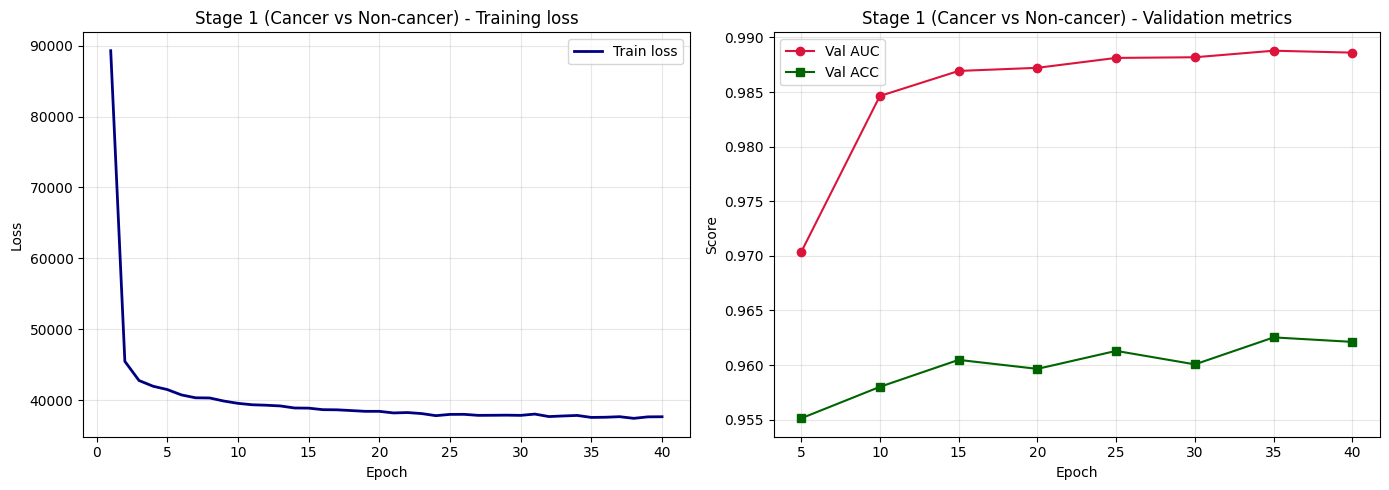

------------------------------
FINAL TEST RESULTS (N=2429)
------------------------------
Test Loss:  37838.5098
ROC-AUC:    0.9872
Accuracy:   0.9601
Precision:  0.9416 (Positive Predictive Value)
Recall:     0.9966 (Sensitivity)
F1-Score:   0.9683
------------------------------
Stage 1 test AUC: 0.9872 | ACC: 0.9601


In [16]:
# Stage 1: cancer vs non-cancer
if "panc_counts" not in globals() or "panc_meta" not in globals() or "panc_maps" not in globals():
    panc_counts, panc_meta, panc_maps, panc_info = load_serum_pancancer_dataset(data_mode="normalized", return_info=True)

PANC_SIGNAL_STAGE1 = 256
PANC_REF_STAGE1 = 128
PANC_STAGE1_EPOCHS = 40
PANC_BATCH_SIZE = 32
PANC_FEATURE_METHOD_STAGE1 = "ttest"
PANC_STAGE1_SEED = 42

labels_stage1 = panc_meta["stage1_label"].values.astype(np.float32)

train_idx_s1, val_idx_s1, test_idx_s1 = stratified_train_val_test_indices(
    labels_stage1,
    test_size=0.15,
    val_size=0.15,
    random_state=PANC_STAGE1_SEED,
)

train_counts_s1 = panc_counts.iloc[train_idx_s1]
train_labels_s1 = labels_stage1[train_idx_s1]

signal_cols_stage1 = get_X_features(
    train_counts_s1,
    train_labels_s1,
    method=PANC_FEATURE_METHOD_STAGE1,
    n_features=PANC_SIGNAL_STAGE1,
)
ref_cols_stage1 = get_reference_features(train_counts_s1, n_features=PANC_REF_STAGE1)

stage1_dataset = ZINBDataset(
    panc_counts,
    labels_stage1,
    signal_cols_stage1,
    ref_cols_stage1,
    task_type="binary",
)

stage1_train_loader = DataLoader(Subset(stage1_dataset, train_idx_s1), batch_size=PANC_BATCH_SIZE, shuffle=True)
stage1_val_loader = DataLoader(Subset(stage1_dataset, val_idx_s1), batch_size=PANC_BATCH_SIZE, shuffle=False)
stage1_test_loader = DataLoader(Subset(stage1_dataset, test_idx_s1), batch_size=PANC_BATCH_SIZE, shuffle=False)

model_stage1 = OrionVAE(
    x_dim=len(signal_cols_stage1),
    r_dim=len(ref_cols_stage1),
    z_dim=32,
    n_classes=1,
    task_type="binary",
)

history_stage1 = train_orion(
    model=model_stage1,
    train_loader=stage1_train_loader,
    val_loader=stage1_val_loader,
    epochs=PANC_STAGE1_EPOCHS,
    lr=1e-3,
    device=device,
    recon_mode="mse",
)

plot_history_with_validation(history_stage1, title="Stage 1 (Cancer vs Non-cancer)", eval_every=5)

loss_stage1 = OrionLoss(beta=0.01, gamma=10.0, n_classes=1, task_type="binary", recon_mode="mse").to(device)
stage1_test_probs, stage1_test_targets = evaluate_test_set(
    model_stage1,
    stage1_test_loader,
    loss_stage1,
    device,
)

stage1_test_auc = roc_auc_score(stage1_test_targets, stage1_test_probs)
stage1_test_acc = accuracy_score(stage1_test_targets, (stage1_test_probs > 0.5).astype(int))
print(f"Stage 1 test AUC: {stage1_test_auc:.4f} | ACC: {stage1_test_acc:.4f}")

stage1_artifact = {
    "model": model_stage1,
    "dataset": stage1_dataset,
    "history": history_stage1,
    "signal_cols": signal_cols_stage1,
    "ref_cols": ref_cols_stage1,
    "split_idx": {"train": train_idx_s1, "val": val_idx_s1, "test": test_idx_s1},
}


Stage 2 samples: 9921 | classes: 13
disease_state_normalized
lung cancer                        1699
colorectal cancer                  1596
gastric cancer                     1418
prostate cancer                    1027
pancreatic cancer                   851
breast cancer                       675
esophageal squamous cell cancer     566
biliary tract cancer                402
ovarian cancer                      400
bladder cancer                      399
hepatocellular cancer               348
bone and soft tissue sarcomas       299
intraparenchymal brain tumors       241
Name: count, dtype: int64
Starting training on cpu for 40 epochs (recon_mode=mse)...
Epoch 005 | Loss: 14923.5298 | Val AUC: 0.6937 | Val Acc: 0.2372
Epoch 010 | Loss: 11391.6672 | Val AUC: 0.7966 | Val Acc: 0.3051
Epoch 015 | Loss: 10483.1411 | Val AUC: 0.8261 | Val Acc: 0.3609
Epoch 020 | Loss: 10339.0581 | Val AUC: 0.8367 | Val Acc: 0.3911
Epoch 025 | Loss: 9964.9842 | Val AUC: 0.8621 | Val Acc: 0.4106
Epoch 030 

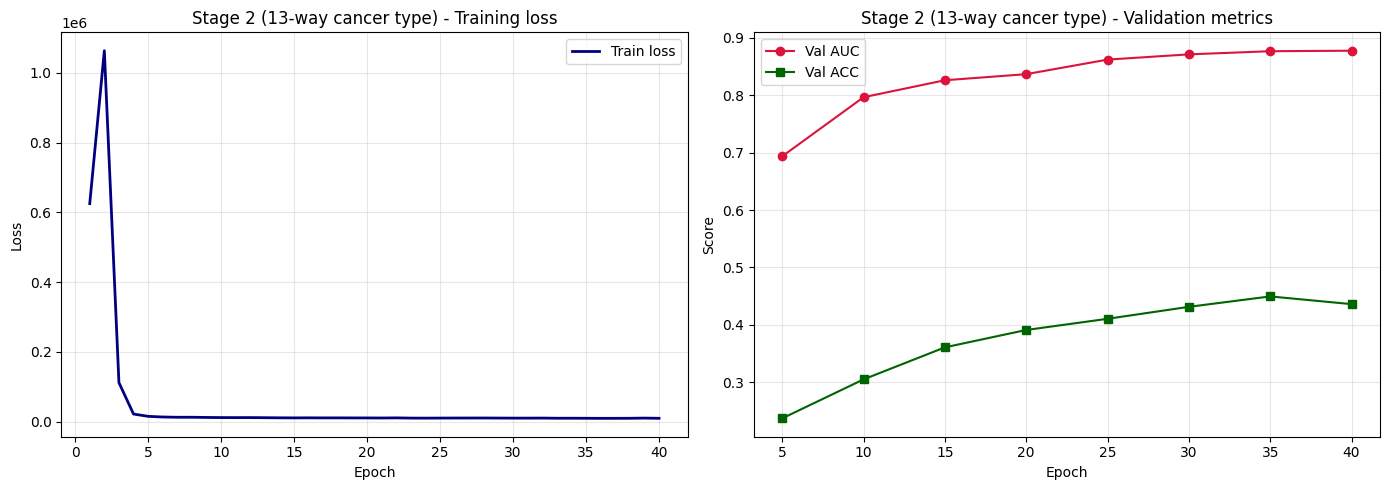

------------------------------
FINAL TEST RESULTS (N=1489)
------------------------------
Test Loss:        10189.7316
ROC-AUC (macro):  0.8716
Accuracy:         0.4332
F1 macro:         0.3421
F1 weighted:      0.3990
------------------------------
Stage 2 test AUC (macro OVR): 0.8716 | ACC: 0.4332 | F1-macro: 0.3421


In [17]:
# Stage 2: cancer-only, 13-type multiclass classification
cancer_mask = panc_meta["stage2_label"].values >= 0
counts_stage2 = panc_counts.loc[cancer_mask]
meta_stage2 = panc_meta.loc[cancer_mask].copy()
labels_stage2 = meta_stage2["stage2_label"].values.astype(int)

n_classes_stage2 = int(labels_stage2.max()) + 1
print("Stage 2 samples:", len(labels_stage2), "| classes:", n_classes_stage2)
print(meta_stage2["disease_state_normalized"].value_counts())

PANC_SIGNAL_STAGE2 = 256
PANC_REF_STAGE2 = 128
PANC_STAGE2_EPOCHS = 40
PANC_BATCH_SIZE_STAGE2 = 32
PANC_STAGE2_SEED = 42

train_idx_s2, val_idx_s2, test_idx_s2 = stratified_train_val_test_indices(
    labels_stage2,
    test_size=0.15,
    val_size=0.15,
    random_state=PANC_STAGE2_SEED,
)

train_counts_s2 = counts_stage2.iloc[train_idx_s2]
train_labels_s2 = labels_stage2[train_idx_s2]

signal_cols_stage2 = select_multiclass_signal_features_anova(
    train_counts_s2,
    train_labels_s2,
    n_features=PANC_SIGNAL_STAGE2,
)
ref_cols_stage2 = get_reference_features(train_counts_s2, n_features=PANC_REF_STAGE2)

stage2_dataset = ZINBDataset(
    counts_stage2,
    labels_stage2,
    signal_cols_stage2,
    ref_cols_stage2,
    task_type="multiclass",
)

stage2_train_loader = DataLoader(Subset(stage2_dataset, train_idx_s2), batch_size=PANC_BATCH_SIZE_STAGE2, shuffle=True)
stage2_val_loader = DataLoader(Subset(stage2_dataset, val_idx_s2), batch_size=PANC_BATCH_SIZE_STAGE2, shuffle=False)
stage2_test_loader = DataLoader(Subset(stage2_dataset, test_idx_s2), batch_size=PANC_BATCH_SIZE_STAGE2, shuffle=False)

model_stage2 = OrionVAE(
    x_dim=len(signal_cols_stage2),
    r_dim=len(ref_cols_stage2),
    z_dim=32,
    n_classes=n_classes_stage2,
    task_type="multiclass",
)

history_stage2 = train_orion(
    model=model_stage2,
    train_loader=stage2_train_loader,
    val_loader=stage2_val_loader,
    epochs=PANC_STAGE2_EPOCHS,
    lr=1e-3,
    device=device,
    recon_mode="mse",
)

plot_history_with_validation(history_stage2, title="Stage 2 (13-way cancer type)", eval_every=5)

loss_stage2 = OrionLoss(
    beta=0.01,
    gamma=10.0,
    n_classes=n_classes_stage2,
    task_type="multiclass",
    recon_mode="mse",
).to(device)
stage2_test_probs, stage2_test_targets = evaluate_test_set(
    model_stage2,
    stage2_test_loader,
    loss_stage2,
    device,
)

stage2_pred = np.argmax(stage2_test_probs, axis=1)
stage2_test_acc = accuracy_score(stage2_test_targets, stage2_pred)
stage2_test_f1_macro = f1_score(stage2_test_targets, stage2_pred, average="macro", zero_division=0)
stage2_test_auc_macro = _safe_macro_auc(stage2_test_targets, stage2_test_probs)

print(
    f"Stage 2 test AUC (macro OVR): {stage2_test_auc_macro:.4f} | "
    f"ACC: {stage2_test_acc:.4f} | F1-macro: {stage2_test_f1_macro:.4f}"
)

stage2_class_map = panc_maps["stage2_index_to_class"]
stage2_artifact = {
    "model": model_stage2,
    "dataset": stage2_dataset,
    "history": history_stage2,
    "signal_cols": signal_cols_stage2,
    "ref_cols": ref_cols_stage2,
    "split_idx": {"train": train_idx_s2, "val": val_idx_s2, "test": test_idx_s2},
    "class_map": stage2_class_map,
}


c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


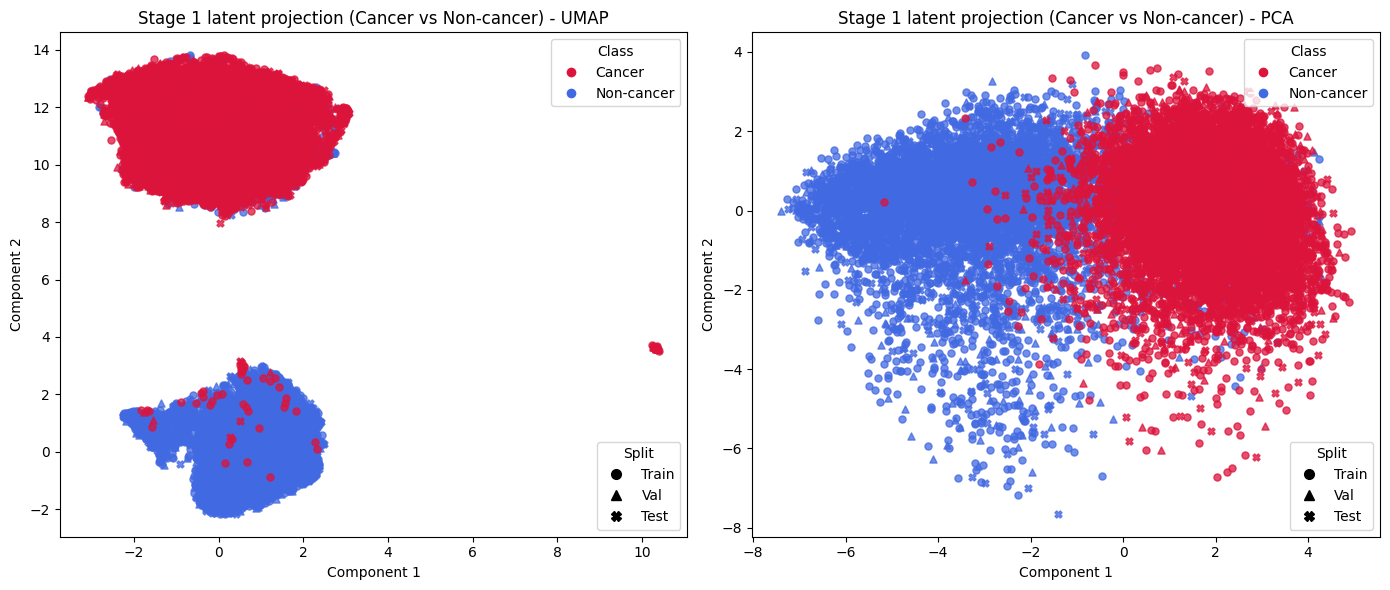

c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\eliaa\AppData\Local\Temp\ipykernel_113364\828939700.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab20", max(len(classes), 13))


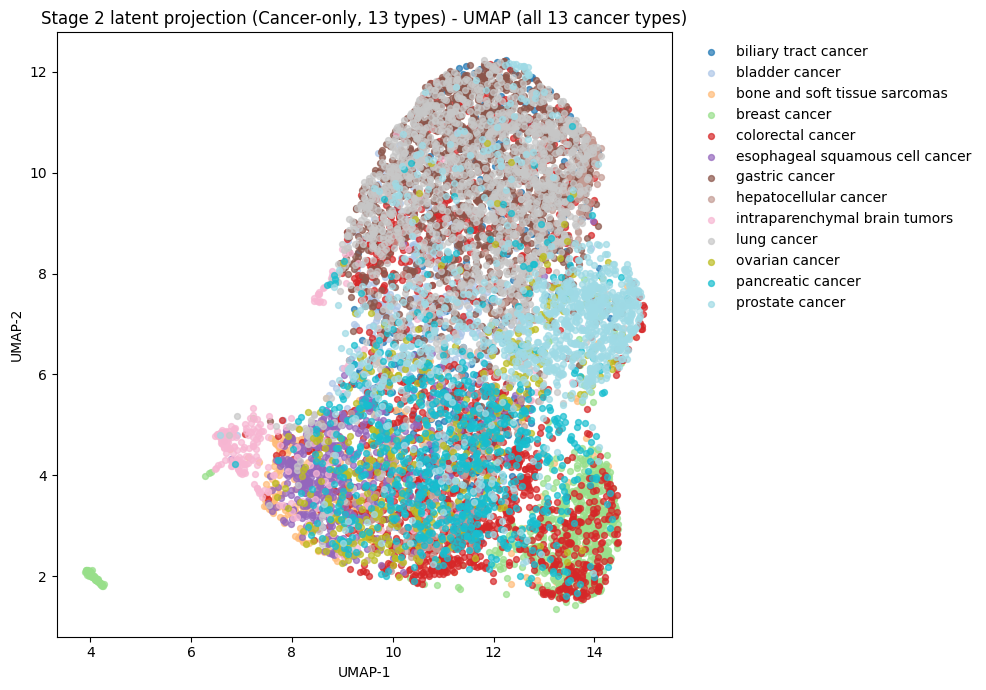

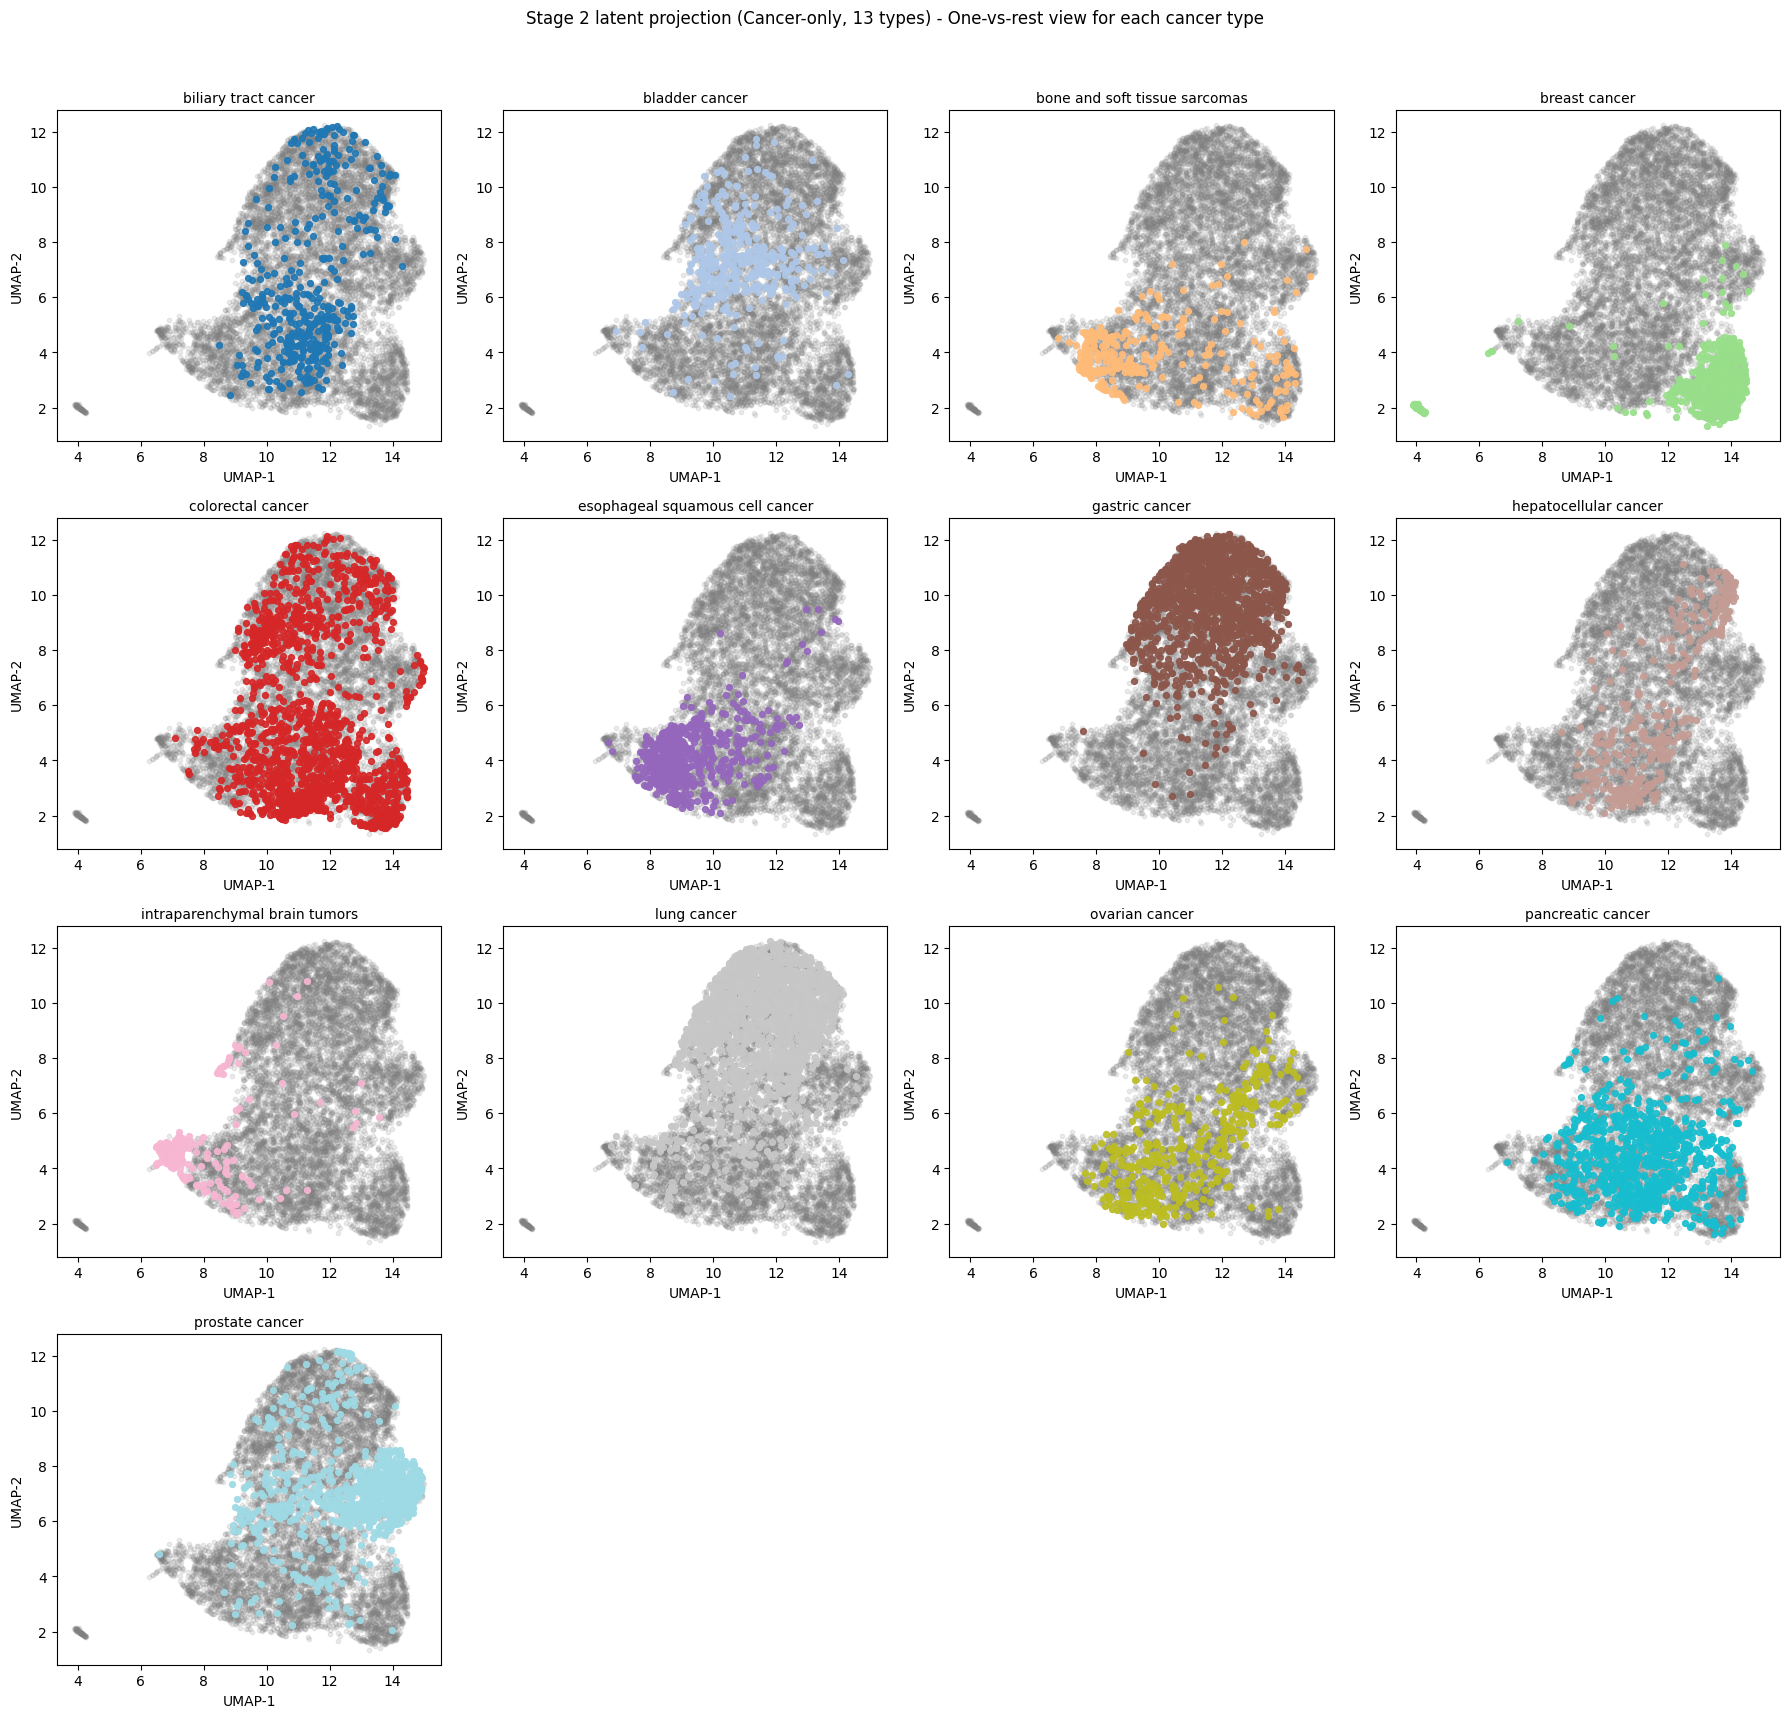

In [18]:
# Latent space analysis
plot_stage1_latent(
    model_obj=stage1_artifact["model"],
    dataset_obj=stage1_artifact["dataset"],
    split_index_map=stage1_artifact["split_idx"],
    batch_size=PANC_BATCH_SIZE,
    device=device,
    title="Stage 1 latent projection (Cancer vs Non-cancer)",
)

plot_stage2_latent(
    model_obj=stage2_artifact["model"],
    dataset_obj=stage2_artifact["dataset"],
    split_index_map=stage2_artifact["split_idx"],
    batch_size=PANC_BATCH_SIZE_STAGE2,
    device=device,
    class_index_to_name=stage2_artifact["class_map"],
    title="Stage 2 latent projection (Cancer-only, 13 types)",
)
